In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:

%cd /content/drive/MyDrive/Manuscript_Segmentation
%pip install -r requirements.txt
!pip install aspose-words

/content/drive/MyDrive/Manuscript_Segmentation


In [74]:
import unicodedata
import pandas as pd
import numpy as np

#1. Извлечение рукописи

In [75]:
# 1. Установка системной утилиты
!apt-get install -y antiword

import os
import re
import unicodedata

def get_raw_lines_from_doc(file_path):
    if not os.path.exists(file_path):
        print(f"Файл {file_path} не найден!")
        return []

    with os.popen(f'antiword "{file_path}"') as pipe:
        text = pipe.read()

    return text.splitlines()

text = get_raw_lines_from_doc('data/193-210.doc')

import re

def get_clean_words(raw_lines):
    # Паттерн: оставляем только нужные буквы, титла и разделитель-точку
    pattern = re.compile(r'[^а-яА-ЯёЁ\u0400-\u04FF\uA640-\uA69F\u0300-\u036F·\-\s]')

    full_text = []

    for line in raw_lines:
        line = re.sub(r'\d+[a-гв]?\s*', '', line).strip()
        # 1. Удаляем всё, что не входит в наш славянский паттерн (цифры пагинации и т.д.)
        line = pattern.sub('', line)
        # 2. Нормализуем пробелы
        line = ' '.join(line.split())
        if line:
            full_text.append(line)

    # Склеиваем всё в одну строку для обработки переносов
    combined_text = " ".join(full_text[1:])

    # 3. Обработка переносов: "же- нѹ" -> "женѹ"
    # Ищем дефис, за которым следуют пробелы и после часть слова
    combined_text = re.sub(r'-\s+', '', combined_text)
    print(combined_text[:100])

    # Очищаем от точек-разделителей, чтобы они не липли к словам в словаре
    words = [w.strip('·') for w in combined_text.split() if len(w.strip('·')) > 0]

    return words

words_corpus = get_clean_words(text)

print(f"Корпус собран. Всего слов: {len(words_corpus)}")
print("Первые 15 слов корпуса:")
print(words_corpus[:15])
#-----Пока не обрабатывает года, но обрабатывает номера страницу, буквы между рукописями

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
antiword is already the newest version (0.37-16).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
безазорнъ҇хъ лиць кромѣ ходѧть · женѹ имать или рабъ҇нѧ · безазорьноѥ себе ѡ семь хранѧ · аще ли пре
Корпус собран. Всего слов: 4687
Первые 15 слов корпуса:
['безазорнъ҇хъ', 'лиць', 'кромѣ', 'ходѧть', 'женѹ', 'имать', 'или', 'рабъ҇нѧ', 'безазорьноѥ', 'себе', 'ѡ', 'семь', 'хранѧ', 'аще', 'ли']


#train_test_split



In [76]:
from sklearn.model_selection import train_test_split

split_index = int(len(words_corpus) * 0.7)
train_text = words_corpus[:split_index]
test_text = words_corpus[split_index:]
words_corpus = train_text

In [77]:
#stemmer  = nltk.SnowballStemmer('russian')
#words_corpus = [stemmer.stem(segment) for segment in words_corpus]

#]==%%time
#snlp = stanza.Pipeline(lang="ru")
#nlp = StanzaLanguage(snlp)

# Разбиваем на два куска, так как максимальная длина входа 1000000 символов
#gap = len(nltk_tokenized_text) // 2
#subtext1 = ' '.join(nltk_tokenized_text[:gap])
#subtext2 = ' '.join(nltk_tokenized_text[gap:])

#doc1 = nlp(subtext1)
#doc2 = nlp(subtext2)

#lemm_text = [token.lemma_ for token in doc1] + [token.lemma_ for token in doc2]


#------- Можно обучать на изменённом lemmit_words_corpusl, а при процессе сегментации проверять lemmited слово из чистого words_corpus

# 2. (Counter) Статистика по словам

In [78]:
from typing import Counter
import nltk, re
from collections import Counter
from nltk.corpus import stopwords

counter = Counter(words_corpus)
df = pd.DataFrame(data = counter.items(), columns = ['Word', 'Count']).sort_values('Count', ascending = False)
df['Word'] = df['Word'].apply(lambda x: x.lower())

# пока что будем брать stopwords тк они могут содержаться в отдельных словах, что может неправильно сегментриовать текст
nltk.download('stopwords')
stop_words =stopwords.words('russian')
df = df[~df['Word'].isin(stop_words)]
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Count
60,въ,87
13,аще,55
61,ѿ,48
228,бѹдеть,27
21,се,27
...,...,...
1511,рода,1
1500,пренесеть,1
1499,пречс̑тѹ,1
1498,прѣданию,1


# Будем состовлять такде биграммы, и находить условную вероятность встречи пары слов в тексте в текущей позиции (для дальнейшего предсказания наличия пробела)
# (слово1б слово2) = (w1, w2)
#  Найдём также условную вероятность птого, что (w2 = couple_words[1]), ghb том что (w1 = couple_words[0]), P(w2|w1) = P(w1 * w2) / P(w1)

# 3. Униграммы, Биграммы

In [79]:
# Counter для биграмм, для двух слов рядом
counter_twice = Counter(zip(words_corpus, words_corpus[1:]))
df_twice = pd.DataFrame(data = counter_twice.items(), columns = ['Word', 'Count']) #.sort_values('Count', ascending = False)
df_twice['Word'] = df_twice['Word'].apply(lambda x: ' '.join(x)).str.lower()
df_twice.sort_values('Count', ascending = False, inplace = True)

df_unigrams = set(df['Word'].values)
df_bigrams = set(df_twice['Word'].values)

def unigram_prob(word :str):
    word = word.lower()
    if word not in df_unigrams:
      return 0
    val = df[df['Word'] == word]['Count']
    return val.values[0] / len(df)

# Найдём также условную вероятность птого, что (w2 = couple_words[1]) при том, что (w1 = couple_words[0]), P(w2|w1) = P(w1 * w2) / P(w1)
def bigram_prob(couple_words):
    w1, w2 = map(str.lower, couple_words)
    if w1 not in df_unigrams:
      return 0
    couple_words = w1 + ' ' + w2
    if couple_words not in df_bigrams:
      return 0
    # уже учитываем условную вероятность
    count_AB = df_twice[df_twice['Word'] == couple_words]['Count'].values[0]
    count_A = df[df['Word'] == w1]['Count'].values[0]

    return count_AB / count_A

print('Распределение частоты биграмм')

counts_of_bigram_counts = df_twice['Count'].value_counts()
counts_of_bigram_counts.name = 'count_of_bigrams_counts'
counts_of_bigram_counts



Распределение частоты биграмм


,count_of_bigrams_counts
Count,
1,2749
2,160
3,33
4,10
5,4
11,1
10,1
9,1
6,1


In [80]:
print('Биграммы')
df_twice

Биграммы


,Word,Count
13,аще ли,11
906,да не,10
21,се же,9
250,и въ,8
54,аще и,7
...,...,...
1043,ѿлѹчити повелѣваѥть,1
1046,потомь не,1
1047,не исправлена,1
1048,исправлена пребъ҇вающа,1


#4. алгоритм Витерби (марковские цепи), модифицированный под задачу сегментации

In [81]:
import math

def viterbi_segment(s, vocab_size, penalty_letter):
    n = len(s)
    dp = [float('-inf')] * (n + 1)
    prev_idx = [-1] * (n + 1)
    last_word_at = [None] * (n + 1) # Храним само слово для биграмм

    dp[0] = 0
    min_word_len = 1
    max_word_len = 15

    # Константы штрафов
    UNK_PENALTY = -20
    LOW_PROB_BIGRAM = math.log(1 / vocab_size) # если биграммы нет в словаре

    # нахождение первого слова
    def seek_first_word():
        best_prob, first_word = float('-inf'), None
        for i in range(1, min(max_word_len, n) + 1):
            # Переводим обычную вероятность в лог
            prob = math.log(unigram_prob(s[:i].lower())) if unigram_prob(s[:i]) > 0 else UNK_PENALTY - i
            if prob > best_prob:
                best_prob = prob
                first_word = s[:i]
        return first_word

    first_w = seek_first_word()
    start = len(first_w)

    dp[start] = math.log(unigram_prob(first_w)) if unigram_prob(first_w) > 0 else UNK_PENALTY - start
    prev_idx[start] = 0
    last_word_at[start] = first_w

    # Алгоритм
    for i in range(start + 1, n + 1):
        best_score = float('-inf')
        best_j, best_word = -1, None

        for L in range(min_word_len, min(max_word_len, i) + 1):
            j = i - L
            word = s[j:i].lower()

  # 1. Unigram score (не только по паре слов предсказываем)
            raw_uni = unigram_prob(word)
            if raw_uni > 0:
                score_word = math.log(raw_uni)
            else:
                # чем меньше длина L, тем штраф сильнее (защита от букв)
                score_word = UNK_PENALTY * (2.0 / L if L <= 2 else 1.0)
            # ---?? сменили знак , чтоб в total_score был правильный знак penalty
            score_word -= penalty_letter / L

  # 2. Bigram score (Conditional score)
            try:
                prev_word = (last_word_at[j]).lower()
            except (IndexError, AttributeError, TypeError):
              conditional_bigram_score = LOW_PROB_BIGRAM

            # p(B|A) = p(AB) / p(A)
            raw_AB = bigram_prob((prev_word, word))
            raw_A = unigram_prob(prev_word)
            if raw_AB > 0 and raw_A > 0:
                conditional_bigram_score = math.log(raw_AB) - math.log(raw_A)
            else:
              conditional_bigram_score = LOW_PROB_BIGRAM

  # conditional probability for couple at position j
  # 3. Score
            # накапливаем ранее найденные score d[j] для позиции j (те который находили для другого раннего слова)
            total_score = dp[j] + conditional_bigram_score + score_word

            if total_score > best_score:
                best_score = total_score
                best_j, best_word = j, s[j:i]

        if best_j != -1:
            dp[i] = best_score
            prev_idx[i] = best_j
            last_word_at[i] = best_word

    # Восстановление
    res = []
    curr = n
    while curr > start:
        current_start = prev_idx[curr]
        if current_start == -1:
            break
        res.append(s[current_start:curr])
        curr = current_start

    res.append(s[:start])
    return res[::-1]

In [82]:
viterbi_segment(''.join(words_corpus), len(df), 100)

['безазорнъ҇хъ',
 'лицькромѣходѧть',
 'женѹиматьилираб',
 'ъ҇нѧбезазорьноѥ',
 'себеѡсемьхранѧа',
 'щелипрестѹпаѥть',
 'ктонамиповелѣна',
 'ӻдаизвержетьс̑с',
 'ежеископьцихран',
 'ѧтьнепорочноѥсе',
 'бепромъ҇шлѧющеп',
 'рестѹпающежеаще',
 'причетничисѹтьд',
 'аизвергѹтьсѧаще',
 'липростьчидаѿтъ',
 'л̑лѹчатьсѧИжеим',
 'ѣтирабъ҇нѧилиин',
 'ъ҇ӻженъ҇ѹсебевд',
 'омѹсщнъ҇мърекше',
 'прозвѹтерѻмъ',
 'ащеископцисѹтьа',
 'щеизѣлосѹтьстар',
 'ъ҇исеправиловъз',
 'бранѧѥтьивелика',
 'говасилиӻкъгриг',
 'орьюпрозвѹтерѹп',
 'осланиѥзапрещаѥ',
 'тьтомѹбъ҇ватитъ',
 'кмоащектоиматьѹ',
 'себевъдомѹженѹѿ',
 'зазорнъ҇хъ',
 'лицьвънихъженѣс',
 '̑боӻзьнинипорок',
 'аӻкожесемтрьили',
 'сестрѹилитеткѹп',
 'оѡциилипомтрире',
 'кшеѻцасвоѥгосес',
 'трѹилимтреилиин',
 'ѹнѣкѹюѿтаковъ҇х',
 'ъпреступающаӻже',
 'правиласиизъвре',
 'щиповелѣваѥмъна',
 'скопцажеболмиис',
 'еправилонаводит',
 'ьӻкоащемирьстии',
 'члвчисѹтьиживѹт',
 'ьвдомѹсъчюжимиж',
 'енамииженесѹтьѿ',
 'зазорьнъ҇хъ',
 'лицьнисродницаи',
 'мъдабдтьѿлчен

# 5. Подбор параметров

In [83]:
import difflib

def validate_on_matcher(words_corpus):
    f1_score, penalty = 0, 0
    penalty_letters = [0.1, 1, 10, 100, 1000] # Добавил промежуточных значений
    predicted, rows_summary = [], []

    real_text = ' '.join(words_corpus)

    for penalty_letter in penalty_letters:
        segmented_list = viterbi_segment(''.join(words_corpus), 40, penalty_letter)
        segmented_text = ' '.join(segmented_list)

        # Используем SequenceMatcher для поиска совпадений границ (Ratio)
        matcher = difflib.SequenceMatcher(None, segmented_text, real_text)

        # Получаем точность посимвольного совпадения
        f1 = matcher.ratio()

        # Если f1 не растет, пробуем посмотреть, как он сегментирует
        print(f"Penalty {penalty_letter}: Accuracy = {f1:.4f}")
        rows_summary.append({
            'Penalty': penalty_letter,
            'F1-Score': f1, })

        if f1 > f1_score:
            f1_score = f1
            penalty = penalty_letter
            predicted = segmented_list

    rows_summary = pd.DataFrame(rows_summary)
    display(rows_summary.style.highlight_max(subset=['F1-Score'], color='lightgreen'))

    return f1_score, penalty, predicted

f1_score, penalty, predicted = validate_on_matcher(words_corpus)
print('\n')
print('Оптимальный параметр:\n')
print(f'Penalty:{penalty}, accuracy: {f1_score}')
print('\n')

Penalty 0.1: Accuracy = 0.8581
Penalty 1: Accuracy = 0.8589
Penalty 10: Accuracy = 0.8168
Penalty 100: Accuracy = 0.4577
Penalty 1000: Accuracy = 0.4241


,Penalty,F1-Score
0,0.100000,0.858103
1,1.000000,0.858896
2,10.000000,0.816803
3,100.000000,0.457735
4,1000.000000,0.424074




Оптимальный параметр:

Penalty:1, accuracy: 0.8588957055214724




In [84]:
list(zip(words_corpus, predicted))

[('безазорнъ҇хъ', 'безазорнъ҇хъ'),
 ('лиць', 'лиць'),
 ('кромѣ', 'кромѣ'),
 ('ходѧть', 'ходѧть'),
 ('женѹ', 'женѹ'),
 ('имать', 'иматьилирабъ҇нѧ'),
 ('или', 'безазорьноѥсебе'),
 ('рабъ҇нѧ', 'ѡсемьхранѧащели'),
 ('безазорьноѥ', 'престѹпаѥтьктон'),
 ('себе', 'амиповелѣнаӻда'),
 ('ѡ', 'извержетьс̑'),
 ('семь', 'се'),
 ('хранѧ', 'жеископьци'),
 ('аще', 'хранѧть'),
 ('ли', 'непорочноѥ'),
 ('престѹпаѥть', 'себе'),
 ('кто', 'промъ҇шлѧюще'),
 ('нами', 'престѹпающе'),
 ('повелѣнаӻ', 'жеащепричетничи'),
 ('да', 'сѹтьдаизвергѹть'),
 ('извержетьс̑', 'сѧащелипростьчи'),
 ('се', 'даѿтъл̑лѹчатьсѧ'),
 ('же', 'Иже'),
 ('и', 'имѣти'),
 ('скопьци', 'рабъ҇нѧ'),
 ('хранѧть', 'илиинъ҇ӻженъ҇ѹс'),
 ('непорочноѥ', 'ебевдомѹсщнъ҇мъ'),
 ('себе', 'рекше'),
 ('промъ҇шлѧюще', 'прозвѹтерѻмъ'),
 ('престѹпающе', 'аще'),
 ('же', 'ископцисѹтьащеи'),
 ('аще', 'зѣло'),
 ('причетничи', 'сѹть'),
 ('сѹть', 'старъ҇'),
 ('да', 'исеправиловъзбр'),
 ('извергѹтьсѧ', 'анѧѥтьивеликаго'),
 ('аще', 'василиӻ'),
 ('ли', 'къ'),
 ('прост

Penalty 0.1 : F1-Score = 0.6771 (P: 0.8179, R: 0.5777)
Penalty 1   : F1-Score = 0.6770 (P: 0.8188, R: 0.5771)
Penalty 10  : F1-Score = 0.6004 (P: 0.7684, R: 0.4927)
Penalty 50  : F1-Score = 0.2295 (P: 0.3818, R: 0.1640)
Penalty 100 : F1-Score = 0.0916 (P: 0.1669, R: 0.0631)


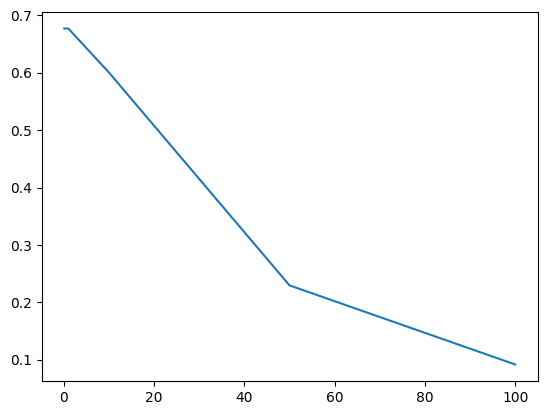

In [92]:
import matplotlib.pyplot as plt
def validate_on_sets(words_corpus):
    f1_score, penalty = 0, 0
    rows_summary = []
    # Сетка параметров для GridSearch
    penalty_letters = [0.1, 1, 10, 50, 100]

    # 1. Строим(set) координат слов из оригинального корпуса
    gold_words = set()
    current_idx = 0
    for word in words_corpus:
        gold_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    solid_text = ''.join(words_corpus)

    for penalty_letter in penalty_letters:
        segmented_list = viterbi_segment(solid_text, 40, penalty_letter)

        # 2. Строим НАБОР (set) координат для предсказанных слов
        pred_words = set()
        current_idx = 0
        for word in segmented_list:
            pred_words.add((current_idx, current_idx + len(word), word))
            current_idx += len(word)

        # 3. Считаем True Positives (пересечение множеств координат работает)
        tp = len(gold_words & pred_words)

        precision = tp / len(pred_words) if len(pred_words) > 0 else 0
        recall = tp / len(gold_words) if len(gold_words) > 0 else 0

        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        print(f"Penalty {penalty_letter:<4}: F1-Score = {f1:.4f} (P: {precision:.4f}, R: {recall:.4f})")
        rows_summary.append({
            'Penalty': penalty_letter,
            'F1-Score': f1, })

        if f1 > f1_score:
            f1_score = f1
            penalty = penalty_letter

    rows_summary = pd.DataFrame(rows_summary)
    plt.plot(rows_summary['Penalty'], rows_summary['F1-Score'])

    return f1_score, penalty

# Запуск
f1_score, penalty = validate_on_sets(words_corpus)

#6.Тестировапние

In [86]:
import difflib

best_penalty = penalty
def test(test_text, penalty_letter):
    test_text = ' '.join(test_text)
    segmented_test_list = viterbi_segment(test_text, len(df), penalty_letter)
    segmented_test_text = ' '.join(segmented_test_list)

    # Используем SequenceMatcher для поиска совпадений границ (Ratio)
    matcher = difflib.SequenceMatcher(None, segmented_test_text, test_text)
    f1 = matcher.ratio()

    print(f" Accuracy = {f1:.4f}")
    return f1_score, predicted

f1_score, predicted = test(test_text, best_penalty)
print('\n')

 Accuracy = 0.6685




In [87]:
def test(test_text_corpus, penalty_letter):
    solid_test = ''.join(test_text_corpus)
    segmented_test_list = viterbi_segment(solid_test, len(df), penalty_letter)

    gold_words = set()
    current_idx = 0
    for word in test_text_corpus:
        gold_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    pred_words = set()
    current_idx = 0
    for word in segmented_test_list:
        pred_words.add((current_idx, current_idx + len(word), word))
        current_idx += len(word)

    tp = len(gold_words & pred_words)
    precision = tp/len(pred_words)
    f1 = 2 * (tp/len(pred_words) * tp/len(gold_words)) / (tp/len(pred_words) + tp/len(gold_words)) if len(pred_words)+len(gold_words) > 0 else 0
    print(f"Тестовый F1-Score = {f1:.4f}\n")
    print(f"Тестовый precision = {precision:.4f}\n")

    return f1, precision, segmented_test_list

# Запуск теста
test_f1, predicted_test, segmented_test_list = test(test_text, penalty)

Тестовый F1-Score = 0.0379

Тестовый precision = 0.0679

